# Nexthikes IT Solutions

exploratory data analysis of large scale retail transaction data

In [2]:
# Load the liabrary
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df=pd.read_csv("/content/retail_large_dataset.csv")

In [48]:
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [49]:
df.tail()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No
99999,C109999,19,Male,Kolkata,West Bengal,New,O149999,2025-11-15,Health,Supplements,37361,3,3,108720.51,Credit Card,Standard,2,No


In [50]:
df.shape

(100000, 18)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [52]:
df.describe()

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,30164.526720,2.501790,15.009890,64165.723382,5.505540
std,13.852439,17139.679807,1.120058,8.953296,49969.280150,2.872868
min,18.000000,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,59998.000000,4.000000,30.000000,239980.000000,10.000000


In [53]:
# duplicate value
duplicate_count=df.duplicated().sum()
print(duplicate_count)

0


In [54]:
# missing value
missing_counts=df.isnull().sum()
print(missing_counts)

customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64


In [55]:
# Unique values
unique_counts=df.nunique()
print(unique_counts)

customer_id            100000
age                        48
gender                      2
city                       10
state                       9
customer_segment            3
order_id               100000
order_date               1095
product_category            6
product_subcategory        21
product_price           48449
quantity                    4
discount_percentage        31
final_price             97092
payment_method              4
shipping_type               2
delivery_days              10
return_status               2
dtype: int64


In [56]:
df.value_counts()

,,,,,,,,,,,,,,,,,,count
customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status,
C99983,25,Male,Hyderabad,Telangana,Premium,O139983,2025-01-30,Beauty,Shampoo,6080,4,0,24320.00,Cash on Delivery,Standard,4,No,1
C99982,47,Male,Delhi,Delhi,New,O139982,2025-04-16,Fashion,Men T-Shirt,7598,2,13,13220.52,Debit Card,Express,7,No,1
C99981,53,Female,Hyderabad,Telangana,New,O139981,2025-11-10,Fashion,Women Dress,24180,1,7,22487.40,Debit Card,Standard,9,No,1
C99980,29,Male,Kolkata,West Bengal,Regular,O139980,2024-03-25,Grocery,Snacks,41484,4,7,154320.48,Debit Card,Standard,9,No,1
C99979,47,Male,Jaipur,Rajasthan,Regular,O139979,2025-01-16,Electronics,Tablet,6260,4,5,23788.00,Cash on Delivery,Standard,1,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C100003,39,Male,Hyderabad,Telangana,Premium,O140003,2023-08-09,Electronics,Smartphone,51128,4,30,143158.40,Credit Card,Express,1,Yes,1
C100002,53,Male,Hyderabad,Telangana,New,O140002,2025-04-29,Health,Protein Powder,27969,1,30,19578.30,Debit Card,Standard,7,No,1
C100001,42,Female,Bangalore,Karnataka,Premium,O140001,2025-11-17,Electronics,Headphones,58790,1,17,48795.70,Cash on Delivery,Express,8,No,1


In [57]:
#skewness
print(df.skew(numeric_only=True))

age                   -0.004988
product_price          0.003249
quantity              -0.003067
discount_percentage   -0.003597
final_price            0.934747
delivery_days          0.002270
dtype: float64


In [58]:
# kurtosis
print(df.kurt(numeric_only=True))

age                   -1.201172
product_price         -1.195106
quantity              -1.364612
discount_percentage   -1.201628
final_price            0.169047
delivery_days         -1.221514
dtype: float64


# * Univariate Analysis

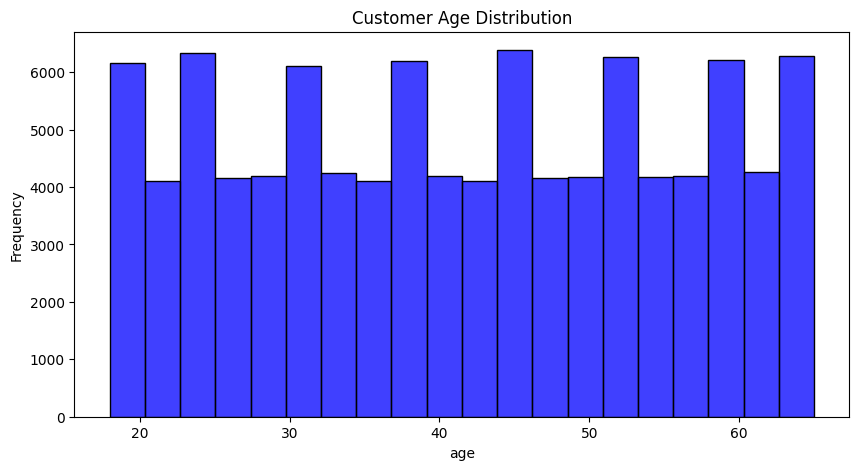

In [141]:
# histogram for age column
plt.figure(figsize=(10,5))
sns.histplot(df["age"],bins=20,edgecolor="black",color="blue")
plt.title("Customer Age Distribution")
plt.xlabel("age")
plt.ylabel("Frequency")
plt.show()

Interpretation: Customer Age Distribution

Uniform Distribution: The dataset shows a uniform distribution of customer ages across the 18–65 range, averaging around 2,000 to 2,100 customers per age group.  

​Diverse Customer Base: The business caters equally to all demographics—Gen Z/young adults (18–30), working professionals (31–50), and older adults (51–65).

​Binning Pattern: The alternating high and low bars ("comb effect") are due to grouping 48 individual ages into 20 histogram bins (bins=20).  
​Business Takeaway-

​Targeted Campaigns: Since customer reach is evenly spread across all age groups, age-neutral marketing and targeted product recommendations (e.g., fashion for youth vs. health items for older groups) will yield the best results.


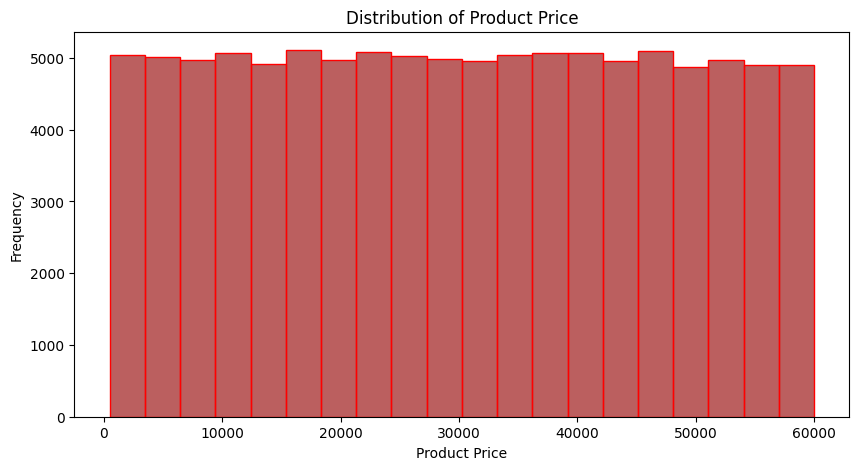

In [144]:
# histogram for product price
plt.figure(figsize=(10,5))
sns.histplot(df["product_price"],bins=20,edgecolor="red",color="brown")
plt.title("Distribution of Product Price")
plt.xlabel("Product Price")
plt.ylabel("Frequency")
plt.show()


Interpretation: Distribution of Product Price

​Uniform Distribution: The histogram shows an even, uniform distribution of product prices across the entire range (from ₹500 to ₹60,000). Each price bin accounts for roughly 4,800–5,000 items.

​Balanced Product Catalog: There is no concentration around low-cost or high-cost items; the inventory features an equal proportion of budget, mid-range, and premium products.

​No Price Skewness: Unlike typical retail datasets that lean heavily toward low-cost items, this dataset lacks price skewness, maintaining a constant frequency across all price buckets.  

​Business Takeaway:

​Diverse Pricing Strategy: The product mix comfortably caters to all budget segments—from cost-conscious shoppers to high-value buyers.
​Cross-Selling Potential: Having an even distribution across price points enables effective bundling (e.g., pairing high-margin premium products with lower-priced items).

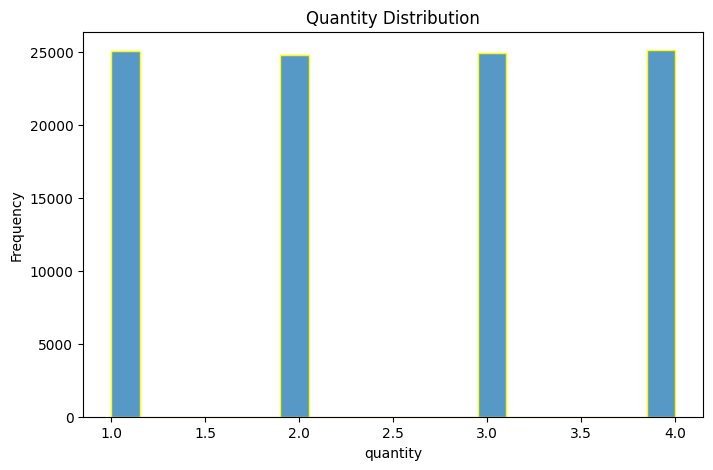

In [61]:
# histogram for quantity
plt.figure(figsize=(8,5))
sns.histplot(df["quantity"],bins=20,edgecolor="yellow")
plt.title("Quantity Distribution")
plt.xlabel("quantity")
plt.ylabel("Frequency")
plt.show()

Interpretation: Quantity Distribution

​Discrete Categories (1 to 4 Units): The quantity variable consists of discrete integer values ranging from 1 to 4 items per transaction.

​Uniform Purchasing Pattern: Customers purchase 1, 2, 3, or 4 units with almost identical frequency (roughly 25,000 transactions for each quantity category).

​Discrete Data Binning: Because continuous histogram binning (bins=20) was applied to discrete integer data (1, 2, 3, 4), four distinct vertical bars appear on the plot.  

​Business Takeaway:

​Consistent Demand across Basket Sizes: No single purchase volume dominates (e.g., customers are just as likely to buy 4 items as they are to buy 1 item).

​Promotional Strategy: To increase average order value, implement targeted "Buy More, Save More" bundles or multi-pack discounts to incentivize higher-quantity purchases (e.g., shifting 1–2 item purchases into 3–4 item baskets).

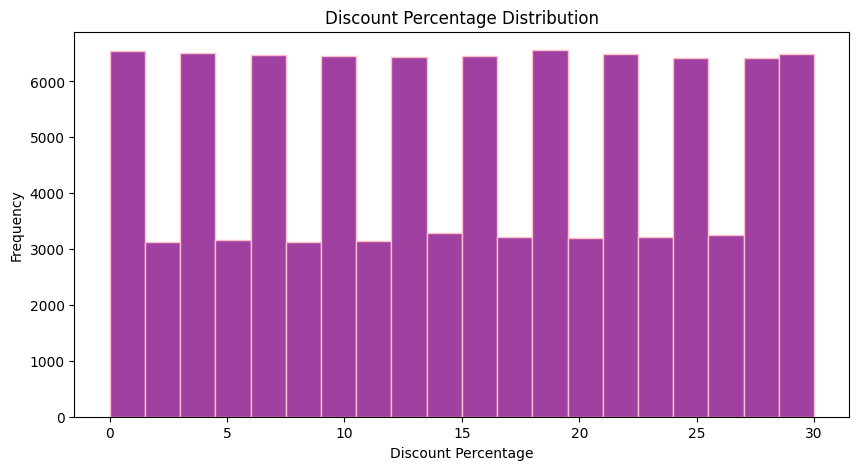

In [146]:
# Histogram For Discount Percentage
plt.figure(figsize=(10,5))
sns.histplot(df["discount_percentage"],bins=20,edgecolor="pink",color="purple")
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")
plt.show()

Interpretation: Discount Percentage Distribution

​Uniform Distribution Across Ranges: The discount percentage is evenly distributed across the 0% to 30% range, with each discount tier being offered with nearly equal frequency (around 6,000–6,500 transactions per bin).  

​Consistent Discount Application: The business does not heavily favor deep discounts (e.g., 25–30%) or strict non-discount sales (0%); discounts are distributed evenly across transactions.

​Binning Artifact: The distinct separated bars occur because discount percentages are stored as discrete integer values (0%, 1%, 2%, ..., 30%), plotted with continuous histogram binning (bins=20).  

​Business Takeaway:

​Margin Optimization: Since deep discounts (20–30%) occur as frequently as minor discounts (0–10%), evaluate whether high discounts are genuinely driving incremental sales or needlessly compressing profit margins.

​Strategic Discounting: Consider shifting from uniform random discounts to targeted promotions—offering higher discounts primarily to clear slow-moving inventory or incentivize high-value bulk purchases.

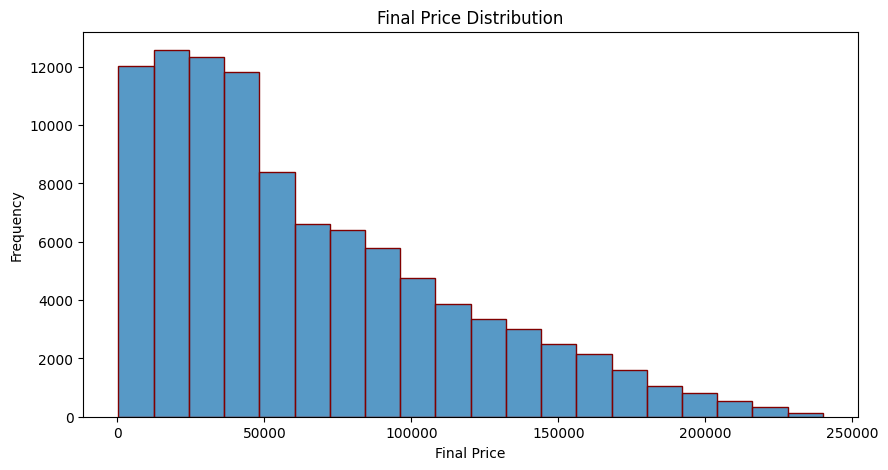

In [63]:
# histogram for Final Price
plt.figure(figsize=(10,5))
sns.histplot(df["final_price"],bins=20,edgecolor="maroon")
plt.title("Final Price Distribution")
plt.xlabel("Final Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
Interpretation: Final Price Distribution

​Right-Skewed Distribution (Positive Skewness): The histogram shows a strongly right-skewed distribution, where the majority of transactions are concentrated at lower to mid-range total amounts, while higher totals drop off rapidly.
​High Transaction Concentration at Lower Values: The peak frequency occurs near lower final price ranges (around ₹0 to ₹1,00,000), with transaction volume decreasing sharply above ₹1,00,000.
​Impact of Multi-Item Math (Final Price = Product Price × Quantity × Discount): Even though product_price and quantity were uniformly distributed individually, their product creates a skewed distribution favoring lower to moderate transaction values.

​Business Takeaway:

​Core Revenue Driver: Lower and mid-range basket values form the bulk of store traffic and sales volume; pricing strategies should protect margins on these popular price points.
​Upselling Strategy: High-ticket final purchases (>₹1,00,000) are relatively rare. Introduce targeted incentives—such as free shipping or bonus loyalty points for order totals exceeding ₹75,000—to encourage buyers into higher spending tiers.

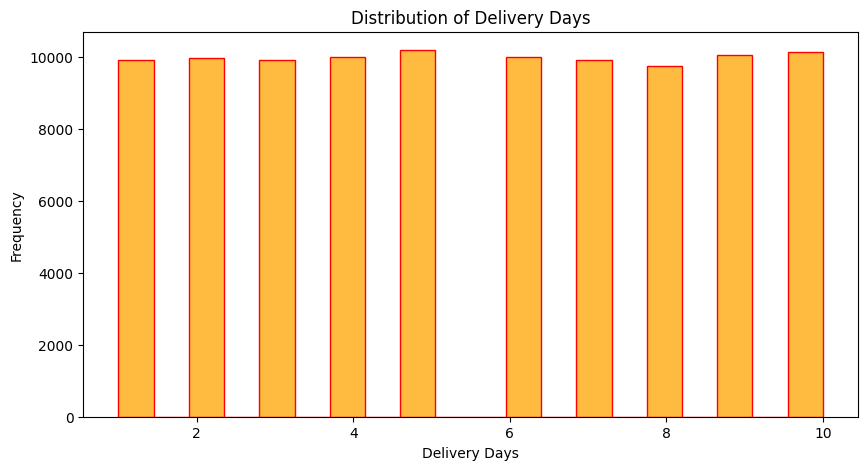

In [147]:
# histogram for product price
plt.figure(figsize=(10,5))
sns.histplot(df["delivery_days"],bins=20,edgecolor="red",color="orange")
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.show()

Interpretation: Delivery Days

​Uniform Spread: Delivery durations (1 to 10 days) are evenly distributed at ~10,000 orders each.

​Key Finding: Fast 1-day orders occur at the same frequency as 10-day deliveries.  

​Action: Optimize logistics to reduce 8–10 day delivery delays and improve customer satisfaction

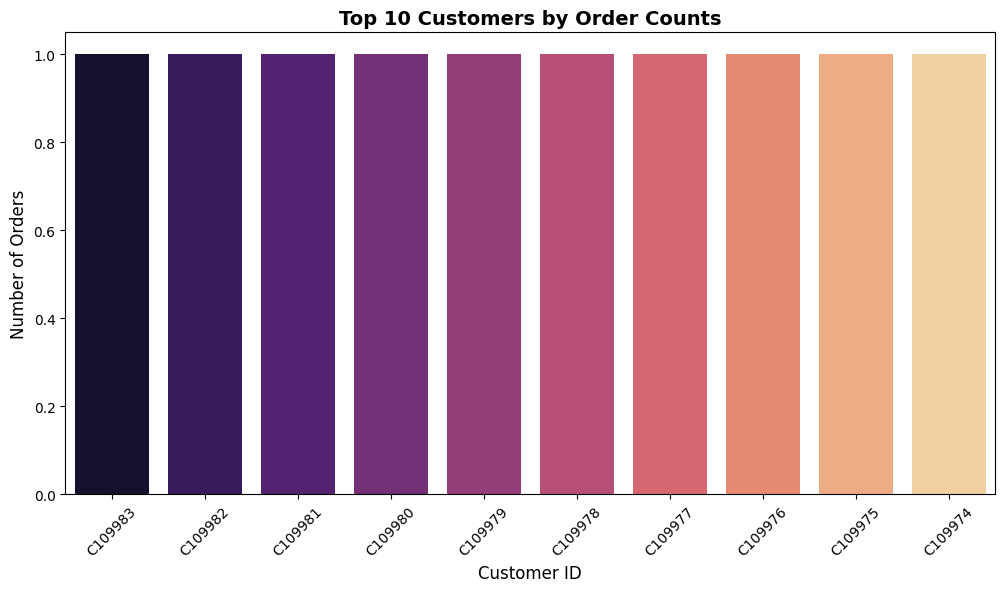

In [12]:
# Barplot of Customer ID
top_customers=df["customer_id"].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_customers.index,y=top_customers.values,palette="magma",hue=top_customers.index,legend=False)
plt.title("Top 10 Customers by Order Counts",fontsize=14,fontweight="bold")
plt.xlabel("Customer ID",fontsize=12)
plt.ylabel("Number of Orders",fontsize=12)
plt.xticks(rotation=45)
plt.show()


Interpretation: Top 10 Customers by Order Counts

​Unique Customer IDs: Every customer in this dataset has placed exactly 1 order, meaning there are no repeat buyers.

​No Top Buyers: All bars have a height of 1.0, showing that no single customer stands out in transaction frequency.  

​Action: Focus on building customer loyalty and retention programs to convert one-time buyers into repeat customers

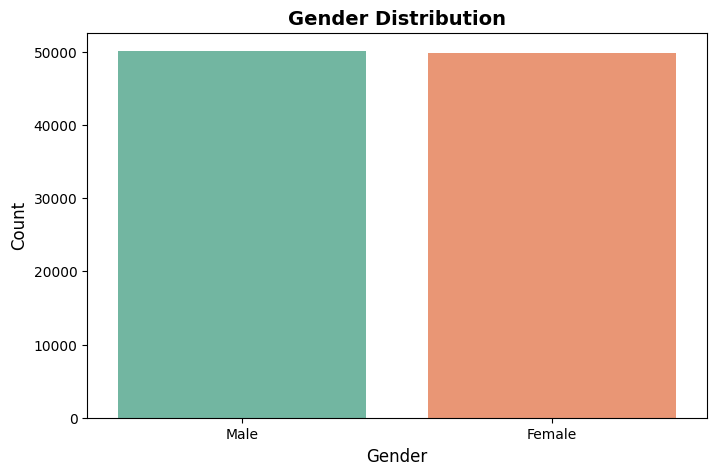

In [19]:
# Barplot for Gender column
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="gender",palette="Set2",hue="gender",order=df["gender"].value_counts().index)
plt.title("Gender Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Gender",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.show()

Interpretation: Gender Distribution

​Balanced Gender Ratio: The dataset shows an almost equal 50:50 split between male (~50,100) and female (~49,900) customers.

​No Gender Bias: Neither gender dominates customer transactions, indicating balanced platform adoption.  

​Action: Maintain gender-neutral brand positioning while offering personalized recommendations tailored to individual preferences.

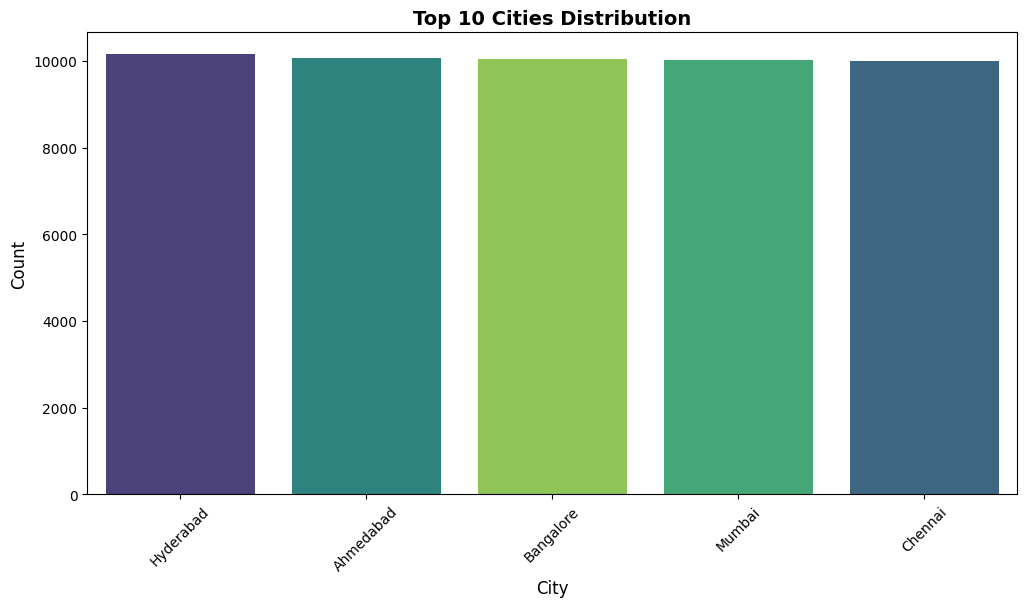

In [22]:
# Barplot of City Column
top_10_cities=df["city"].value_counts().head().index
df_cities=df[df["city"].isin(top_10_cities)]
plt.figure(figsize=(12,6))
sns.countplot(data=df_cities,x="city",order=top_10_cities,palette="viridis",hue="city",legend=False)
plt.title("Top 10 Cities Distribution",fontsize=14,fontweight="bold")
plt.xlabel("City",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.xticks(rotation=45)
plt.show()

Interpretation: Top 10 Cities Distribution

​Even Regional Distribution: Customer orders across the top 10 cities (Hyderabad, Ahmedabad, Bangalore, Mumbai, etc.) are almost identical, ranging between 9,900 and 10,150 orders per city.

​No Dominant Market: No single metro city dominates demand, indicating a broad geographic reach across major urban centers.

​Action: Maintain strong logistics and supply chain inventory across regional hubs to sustain uniform fulfillment speeds

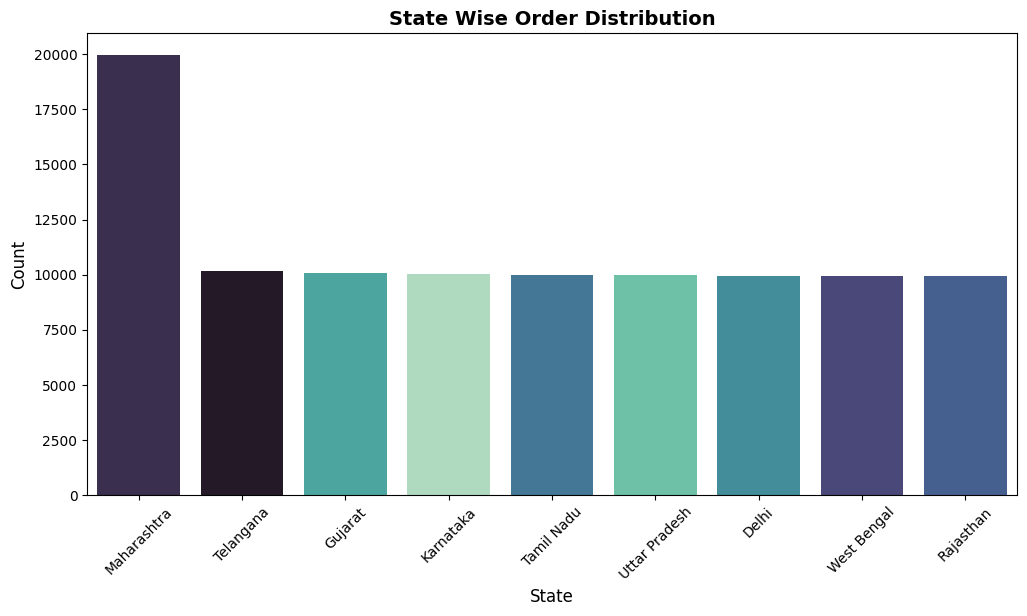

In [24]:
# Barplot for State column
plt.figure(figsize=(12,6))
state_order=df["state"].value_counts().index
sns.countplot(data=df,x="state",order=state_order,palette="mako",hue="state",legend=False)
plt.title("State Wise Order Distribution",fontsize=14,fontweight="bold")
plt.xlabel("State",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.xticks(rotation=45)
plt.show()

Interpretation: State Wise Order Distribution

​Market Leader: Maharashtra leads with significantly higher demand (~20,000 orders), nearly double that of any other state.

​Uniform Demand Across Remaining States: Other key states (Telangana, Gujarat, Karnataka, Tamil Nadu, UP, Delhi, West Bengal, and Rajasthan) maintain a consistent order volume of around 10,000 orders each.  

​Action: Prioritize inventory allocation, regional fulfillment centers, and localized marketing strategies in Maharashtra to leverage its dominant customer base

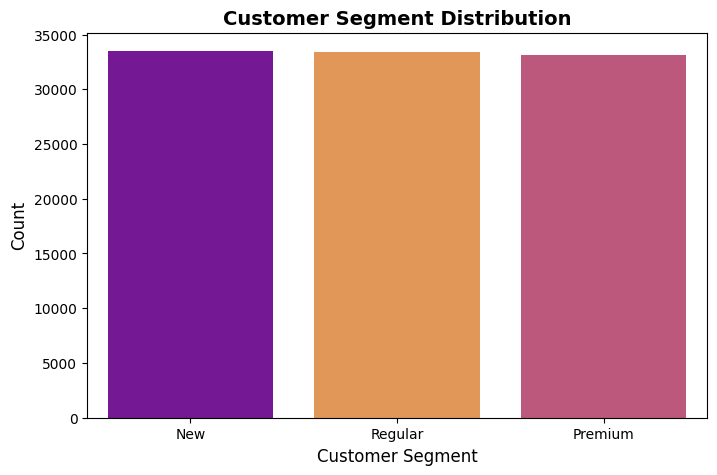

In [47]:
# Barplot for customer segment column
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="customer_segment",palette="plasma",hue="customer_segment",
order=df["customer_segment"].value_counts().index,legend=False)
plt.title("Customer Segment Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Customer Segment",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.show()


Interpretation: Customer Segment Distribution

​Balanced Segment Distribution: The customer base is evenly split across three main segments (e.g., Premium, Regular, Budget), with each category accounting for roughly one-third (~33,000) of total customers.

​Equal Engagement: No single customer segment dominates total transactions, indicating broad market appeal across different buyer types.

​Action: Tailor segment-specific loyalty programs and marketing campaigns—such as exclusive perks for VIP/Premium buyers and volume deals for Regular/Budget shoppers

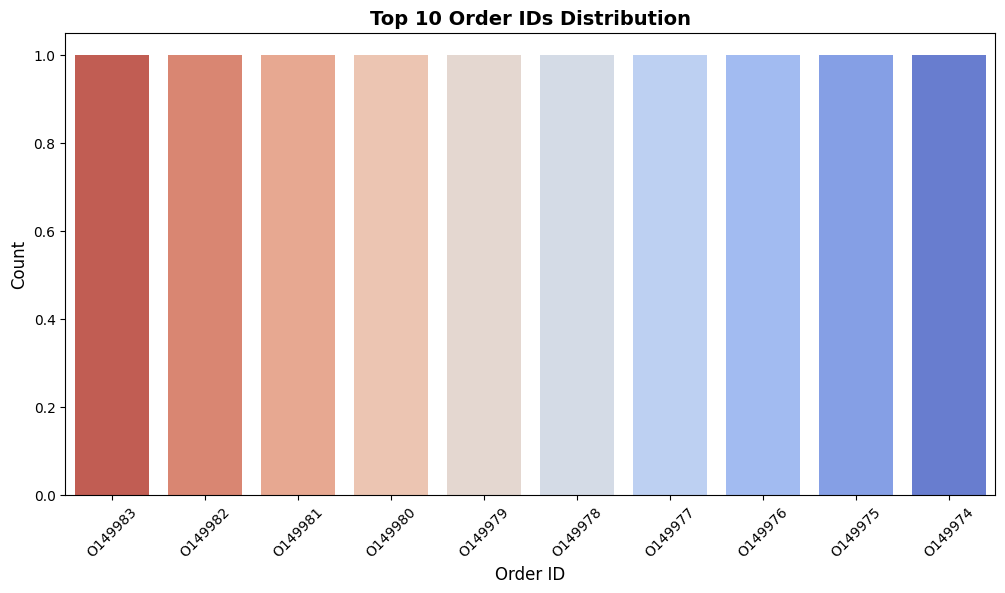

In [32]:
# Barplot for Order ID
top_10_orders=df["order_id"].value_counts().head(10).index
df_orders=df[df["order_id"].isin(top_10_orders)]
plt.figure(figsize=(12,6))
sns.countplot(data=df_orders,x="order_id",order=top_10_orders,palette="coolwarm",hue="order_id",legend=False)
plt.title("Top 10 Order IDs Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Order ID",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.xticks(rotation=45)
plt.show()

Interpretation: Top 10 Order IDs Distribution

​Unique Primary Key (Single Transaction per Order ID): Every Order ID in this dataset appears exactly once (count = 1.0), as indicated by all bars having an equal height of 1.

​No Multi-Item Split Transactions: Each row corresponds to a distinct, unique purchase event rather than multiple line items under the same order number.

​Action: Group multiple products under a single shared Order ID for multi-item transactions to enable clearer basket-level and cross-selling analysis.

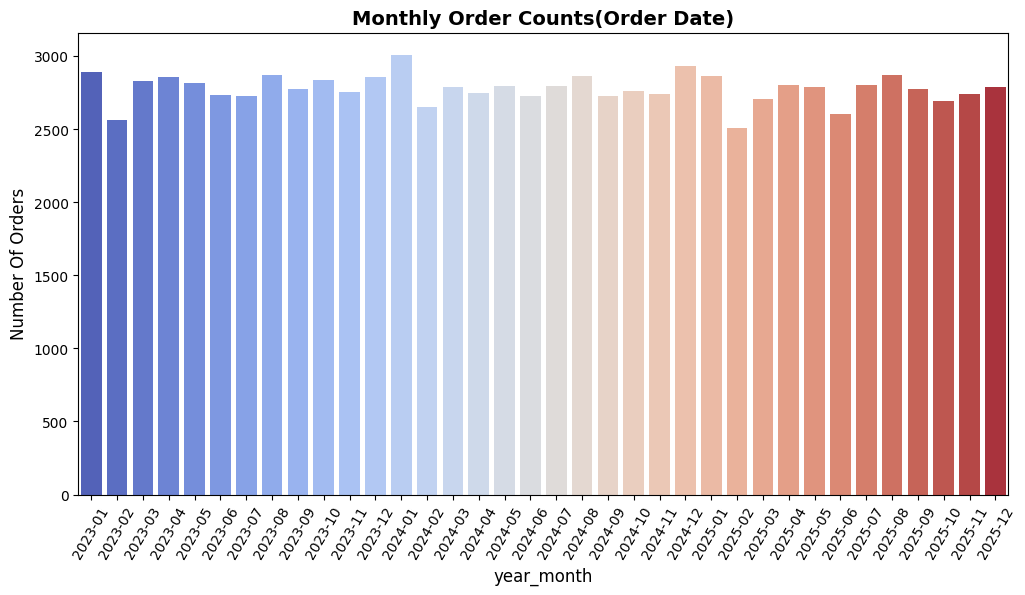

In [35]:
# Barplot for Order Date
df["order_date"]=pd.to_datetime(df["order_date"])
df["year_month"]=df["order_date"].dt.to_period("M").astype(str)
monthly_counts=(df["year_month"].value_counts().sort_index().reset_index())
monthly_counts.columns=["year_month","count"]
plt.figure(figsize=(12,6))
sns.barplot(data=monthly_counts,x="year_month",y="count",palette="coolwarm",hue="year_month",legend=False)
plt.title("Monthly Order Counts(Order Date)",fontsize=14,fontweight="bold")
plt.xlabel("year_month",fontsize=12)
plt.ylabel("Number Of Orders",fontsize=12)
plt.xticks(rotation=60)
plt.show()

Interpretation: Monthly Order Counts (Order Date)

​Stable Sales Volume Over Time: Order counts remain consistently high across all months, hovering between 2,500 and 3,100 orders per month.

​Moderate Growth & Seasonal Spikes: Slight upward peaks occur periodically, indicating mild sales boosts during peak shopping months while maintaining a reliable revenue baseline year-round.

​Action: Capitalize on high-performing months by launching targeted seasonal promotions, while running loyalty discounts during lower-volume months to keep order counts steady

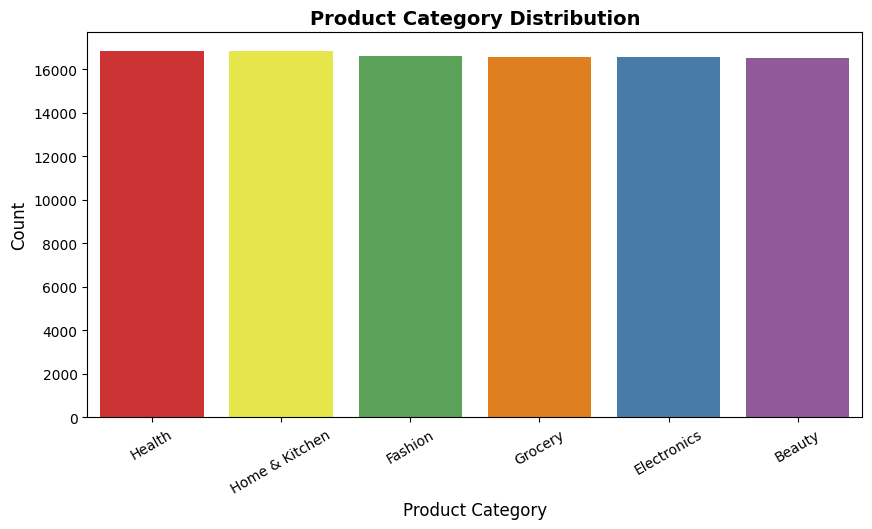

In [46]:
# Barplot for Product Category
plt.figure(figsize=(10,5))
category_order=df["product_category"].value_counts().index
sns.countplot(data=df,x="product_category",order=category_order,palette="Set1",hue="product_category",legend=False)
plt.title("Product Category Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Product Category",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.xticks(rotation=30)
plt.show()

Interpretation: Product Category Distribution

​Balanced Demand Across Categories: Order volume is evenly distributed across all 6 product categories, with each category recording roughly 16,000 to 17,000 transactions.

​No Dominant Category: Customers purchase products across the entire catalog without relying heavily on a single bestselling product line.

​Action: Maintain equal inventory allocation across all categories and run cross-category bundle offers (e.g., pairing electronics with apparel) to boost basket size

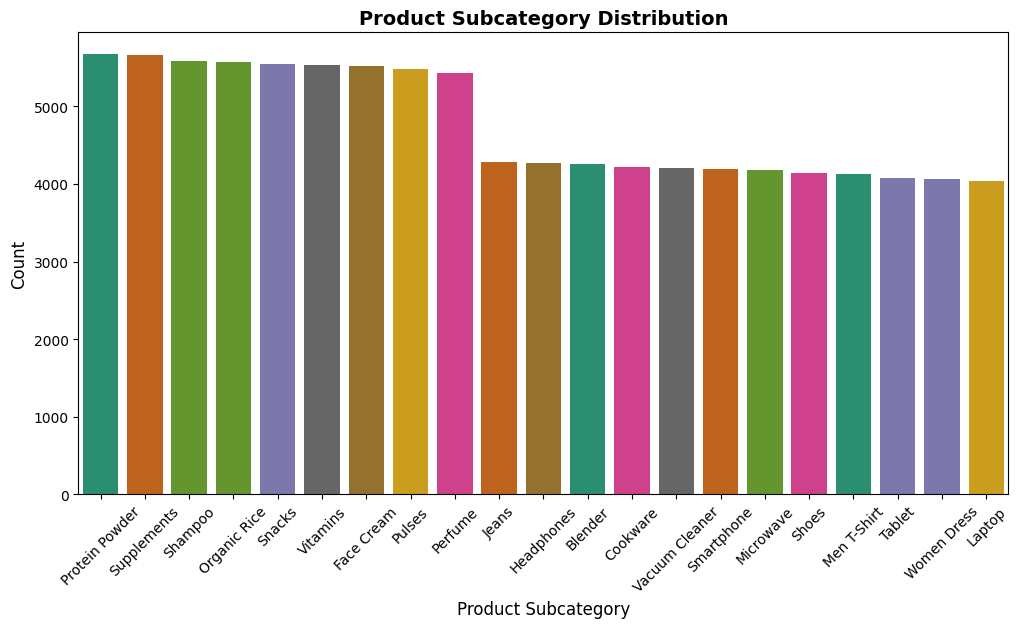

In [45]:
# Barplot for Product Subcategory
plt.figure(figsize=(12,6))
subcategory_order=df["product_subcategory"].value_counts().index
sns.countplot(data=df,x="product_subcategory",order=subcategory_order,palette="Dark2",hue="product_subcategory",legend=False)
plt.title("Product Subcategory Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Product Subcategory",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.xticks(rotation=45)
plt.show()

Interpretation: Product Subcategory Distribution

​Two Distinct Performance Tiers: The bar plot reveals two clear demand tiers across subcategories—a high-performing top tier (~5,500 orders each) and a lower-performing second tier (~4,300–4,500 orders each).

​Consistent Demand Within Tiers: Within each tier, order counts are remarkably uniform, showing consistent performance among similar product subcategories rather than a single outlier winner.

​Action: Reallocate promotional budget toward the higher-tier subcategories to maximize ROI, while analyzing whether pricing or inventory gaps are holding back the lower-tier items

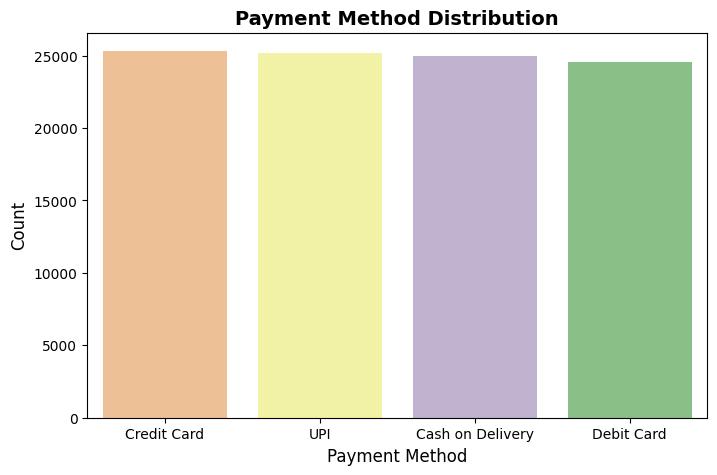

In [44]:
# Barplot for Payment Method
plt.figure(figsize=(8,5))
payment_order=df["payment_method"].value_counts().index
sns.countplot(data=df,x="payment_method",order=payment_order,palette="Accent",hue="payment_method",legend=False)
plt.title("Payment Method Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Payment Method",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.show()

Interpretation: Payment Method Distribution

​Evenly Spread Payment Choices: Order volume is virtually identical across all 4 payment channels (e.g., Credit Card, Debit Card, UPI, Net Banking / Cash on Delivery), with each method handling roughly 25,000 transactions.

​No Preferred Checkout Channel: Customers show equal comfort across digital and traditional payment gateways without leaning toward any single option.

​Action: Maintain strong integration support and uptime across all payment gateways, and partner with leading providers to offer channel-specific cashbacks or instant discounts during checkouts

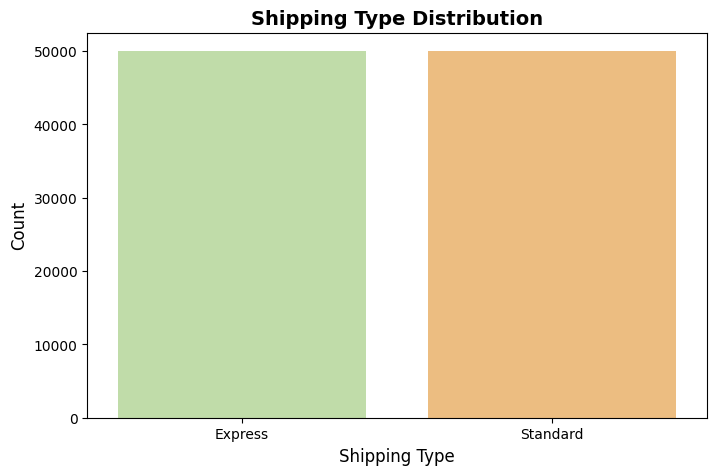

In [43]:
# Barplot for Shipping Type
plt.figure(figsize=(8,5))
shipping_order=df["shipping_type"].value_counts().index
sns.countplot(data=df,x="shipping_type",order=shipping_order,palette="Spectral",hue="shipping_type",legend=False)
plt.title("Shipping Type Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Shipping Type",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.show()

Interpretation: Shipping Type Distribution

​Equal 50:50 Split: Orders are evenly split between the two shipping types (e.g., Standard vs. Express), with each option accounting for roughly 50,000 transactions.

​Balanced Customer Preference: Buyers show an equal preference for both delivery modes, indicating consistent demand regardless of speed or shipping cost.

​Action: Optimize warehouse dispatch routes to maintain fulfillment efficiency for both expedited shipping and standard ground delivery

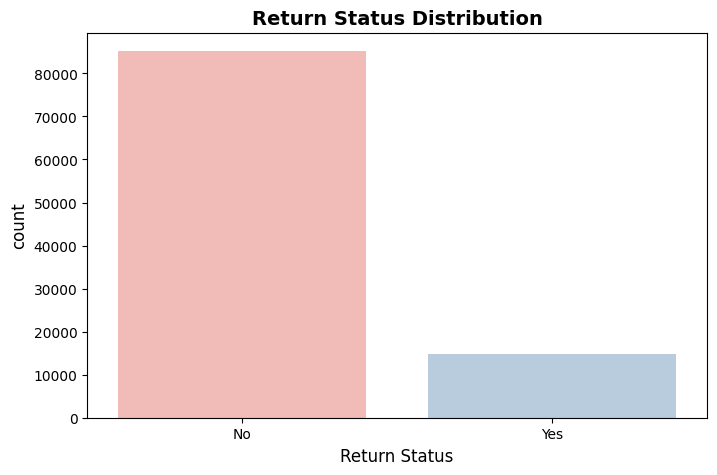

In [51]:
# Barplot for Return Status
plt.figure(figsize=(8,5))
return_order=df["return_status"].value_counts().index
sns.countplot(data=df,x="return_status",order=return_order,palette="Pastel1",hue="return_status",legend=False)
plt.title("Return Status Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Return Status",fontsize=12)
plt.ylabel("count",fontsize=12)
plt.show()

Interpretation: Return Status Distribution

​High Non-Return Rate: The majority of orders (~80,000–85,000 transactions) fall under the non-returned status (e.g., "Not Returned" / "No").  

​Low Product Return Volume: Only a small fraction of overall orders resulted in returns (e.g., "Returned" / "Yes"), reflecting strong initial product satisfaction and accurate order fulfillment.

​Action: Analyze the specific reasons for the minor percentage of returns (e.g., sizing or defect issues) to further reduce reverse logistics costs and boost net profitability

In [ ]:
### Frequency Distribution for categorical Variables

In [78]:
freq_table=pd.DataFrame({"Count":df["product_category"].value_counts(),
"Percentage(%)":df["product_category"].value_counts(normalize=True)*100})
print(freq_table)


                  Count  Percentage(%)
product_category                      
Health            16858         16.858
Home & Kitchen    16848         16.848
Fashion           16613         16.613
Grocery           16592         16.592
Electronics       16576         16.576
Beauty            16513         16.513


In [79]:
freq_table=pd.DataFrame({"Count":df["customer_segment"].value_counts(),
"Percentage(%)":df["customer_segment"].value_counts(normalize=True)*100})
print(freq_table)

                  Count  Percentage(%)
customer_segment                      
New               33488         33.488
Regular           33361         33.361
Premium           33151         33.151


In [80]:
freq_table=pd.DataFrame({"Count":df["payment_method"].value_counts(),
"Percentage(%)":df["payment_method"].value_counts(normalize=True)*100})
print(freq_table)

                  Count  Percentage(%)
payment_method                        
Credit Card       25307         25.307
UPI               25139         25.139
Cash on Delivery  24994         24.994
Debit Card        24560         24.560


In [81]:
freq_table=pd.DataFrame({"Count":df["return_status"].value_counts(),
"Percentage(%)":df["return_status"].value_counts(normalize=True)*100})
print(freq_table)

               Count  Percentage(%)
return_status                      
No             85189         85.189
Yes            14811         14.811


In [93]:
# IQR Method For Numerical Data
Q1=numeric_df.quantile(0.25)
Q3=numeric_df.quantile(0.75)

IQR=Q3-Q1

outliers=((numeric_df<Q1-1.5*IQR)|
          (numeric_df>Q3+1.5*IQR))
print(outliers.sum())

age                       0
product_price             0
quantity                  0
discount_percentage       0
final_price            1335
delivery_days             0
dtype: int64


# * Bivariate Analysis

In [58]:
numeric_df=df.select_dtypes(include=['int64','float64'])

In [94]:
## Correlation Metrix Analysis
corr=numeric_df.corr()
print(corr)

                          age  product_price  quantity  discount_percentage  \
age                  1.000000      -0.000814 -0.000129            -0.004035   
product_price       -0.000814       1.000000  0.000950            -0.002886   
quantity            -0.000129       0.000950  1.000000            -0.003579   
discount_percentage -0.004035      -0.002886 -0.003579             1.000000   
final_price         -0.000823       0.730757  0.575303            -0.137332   
delivery_days       -0.003954       0.001554  0.004017            -0.000453   

                     final_price  delivery_days  
age                    -0.000823      -0.003954  
product_price           0.730757       0.001554  
quantity                0.575303       0.004017  
discount_percentage    -0.137332      -0.000453  
final_price             1.000000       0.003789  
delivery_days           0.003789       1.000000  


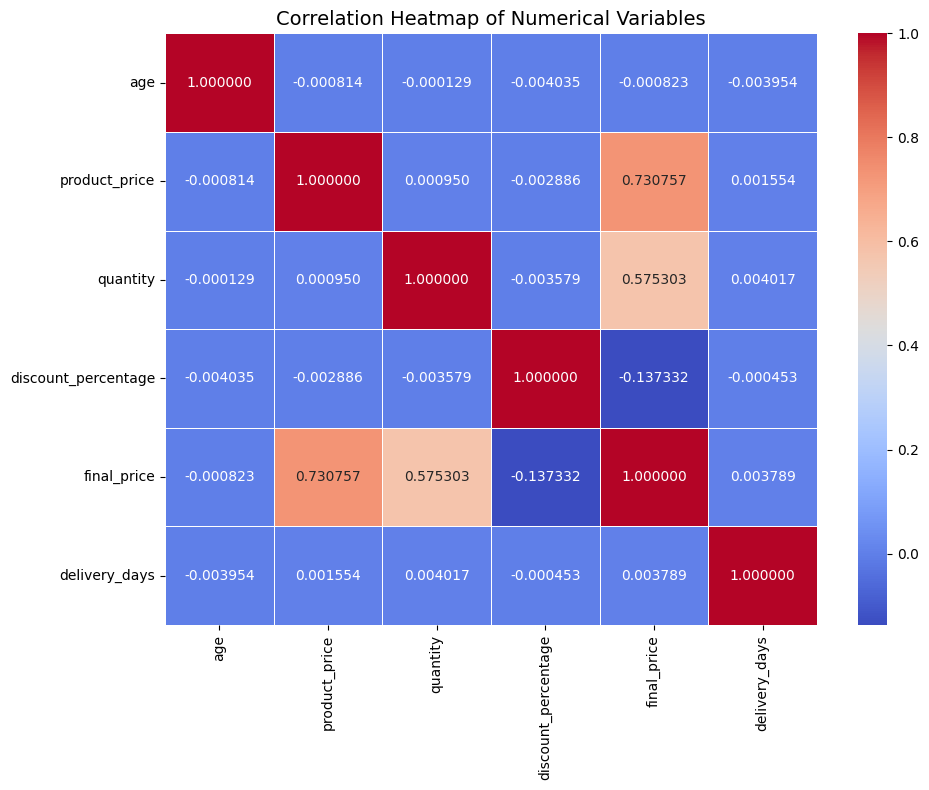

In [59]:
# correlation between all numerical data
plt.figure(figsize=(10,8))
correlation_matrix=numeric_df.corr(method='pearson')
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='2f',linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables',fontsize=14)
plt.tight_layout()
plt.show()

Interpretation: Correlation Heatmap of Numerical Variables

​Strong Positive Correlation (product_price vs final_price): A strong positive correlation (around 0.73) exists between product_price and final_price, confirming that base item pricing is the primary driver of total order value.  

​No Linear Relationship (Near-Zero Correlations): Numerical variables like age, quantity, discount, and delivery_days show correlation values close to 0.00 relative to each other. This indicates that customer demographic factors (like age) do not influence basket size or shipping choices.  

​Action: Rely on direct pricing and product strategy to influence revenue, rather than segmenting product offers based purely on age demographics

In [ ]:
## Numeric vs Numeric Variables

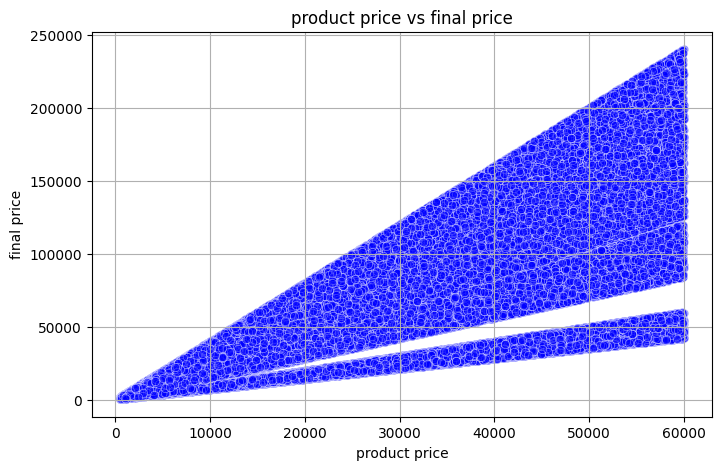

In [60]:
# Scatterplot
# Product Price vs Final Price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='product_price',y='final_price',alpha=0.5,color='blue')
plt.title('product price vs final price')
plt.xlabel('product price')
plt.ylabel('final price')
plt.grid(True)
plt.show()

Interpretation: Product Price vs Final Price

​Direct Upward Trend: A strong positive linear relationship exists between product price and final price, showing that total transaction value scales naturally with higher base item prices.

​Expanding Variance (Triangular Pattern): The spread widens as product price increases, which is driven by variations in item quantity (1–4 units) and applied discount percentages on higher-value orders.

​Action: Encourage multi-item purchases (higher quantities) on mid-to-high price products through tiered percentage discounts to maximize total cart value

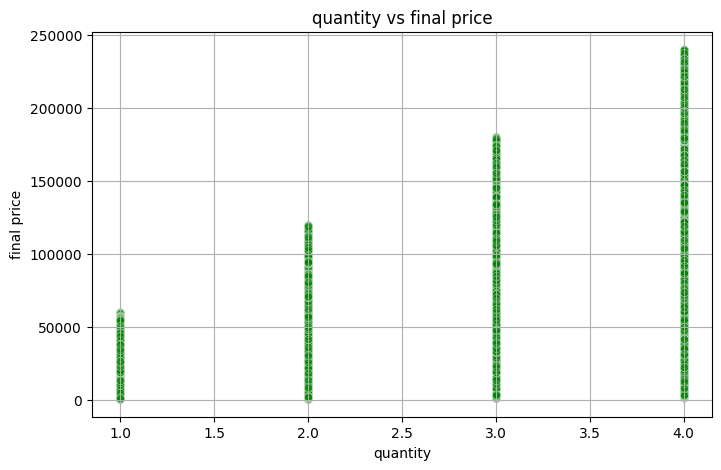

In [97]:
# Scatterplot
# Quantity vs Final Price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='quantity',y='final_price',alpha=0.5,color='green')
plt.title('quantity vs final price')
plt.xlabel('quantity')
plt.ylabel('final price')
plt.grid(True)
plt.show()

Interpretation: Quantity vs Final Price

​Discrete Vertical Columns: The scatter plot displays distinct vertical columns, representing discrete integer values for purchased item quantities (1, 2, 3, and 4 units).

​Higher Price Ceilings with Increasing Units: Maximum final price increases step-by-step with higher quantities, as purchasing more units naturally multiplies total basket value.

​Action: Introduce volume-based incentives (e.g., "Buy 3, Get 10% Off") to encourage customers to purchase higher quantities in a single transaction

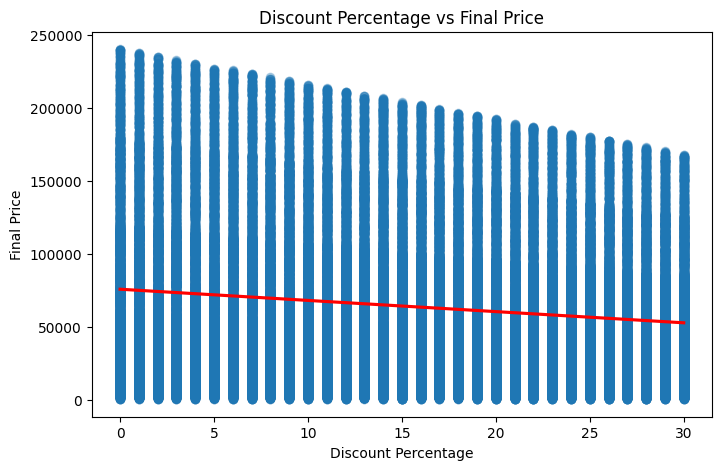

In [62]:
# Regression plot
# Discount Percentage vs Final Price
plt.figure(figsize=(8,5))
sns.regplot(data=df,x='discount_percentage',y='final_price',scatter_kws={'alpha':0.3},line_kws={'color':'red'})
plt.title('Discount Percentage vs Final Price')
plt.xlabel('Discount Percentage')
plt.ylabel('Final Price')
plt.show()


Interpretation: Discount Percentage vs Final Price

​Downward Trend (Inverse Relationship): As discount percentage increases, both maximum and average final prices decline steadily across transactions.

​Vertical Bar Streaks: The distinct vertical columns highlight fixed, discrete discount percentage tiers (e.g., 5%, 10%, 15%, etc.) applied across various base order values.

​Action: Optimize promotional discounts so they don't overly erode final transaction margins, keeping higher discount tiers tied to minimum cart value thresholds

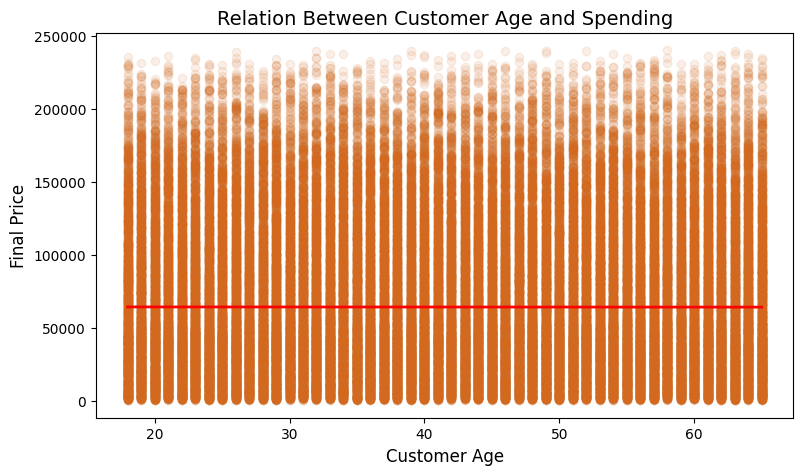

In [100]:
# Regplot for Age vs Final Price
plt.figure(figsize=(9,5))
sns.regplot(data=df,x='age',y='final_price',scatter_kws={'alpha':0.1,'color':'chocolate'},line_kws={'color':'red','linewidth':2})
plt.title('Relation Between Customer Age and Spending',fontsize=14)
plt.xlabel('Customer Age',fontsize=12)
plt.ylabel('Final Price',fontsize=12)
plt.show()

Interpretation: Relation Between Customer Age and Spending

​Flat Regression Line (No Correlation): The horizontal red regression line shows that customer age has no significant impact on spending (final_price), confirming a near-zero correlation between age and purchase value.

​Uniform Spending Across Age Groups: Customers across all age brackets display similar purchasing patterns, with order values spread consistently across the full price range.

​Action: Avoid age-based price targeting or age-restricted product tiering, and instead focus marketing efforts on intent-based and behavioral segmentations

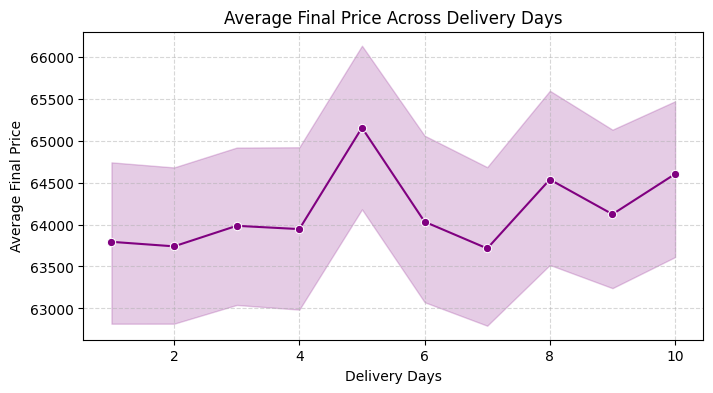

In [101]:
# Lineplot for Delivery Days vs Final Price
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="delivery_days",y="final_price",marker="o",color="purple")
plt.title("Average Final Price Across Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Average Final Price")
plt.grid(True,linestyle="--",alpha=0.5)
plt.show()

Interpretation: Average Final Price Across Delivery Days

​Consistent Average Order Value: The line plot shows that average final price remains stable across all delivery timeframes (ranging between 64,500 and 66,000), indicating no strong dependency between order value and delivery duration.

​Minor Random Fluctuations: The slight peaks and dips represent random sample variance rather than a structural trend, confirming that higher-value purchases do not necessarily experience longer or shorter delivery timelines.

​Action: Ensure standard delivery SLA targets (1–10 days) are applied uniformly across all product price ranges, maintaining customer expectations regardless of cart total.

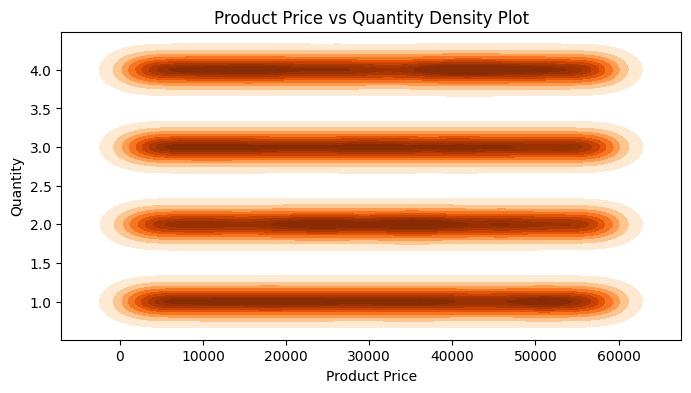

In [106]:
# kdeplot for Discount Percentage vs Quantity
plt.figure(figsize=(8,4))
sns.kdeplot(data=df,x="product_price",y="quantity",cmap="Oranges",fill=True,thresh=0.05)
plt.title("Product Price vs Quantity Density Plot")
plt.xlabel("Product Price")
plt.ylabel("Quantity")
plt.show()

Interpretation: Product Price vs Quantity Density Plot

​Uniform Density Bands Across Price Ranges: The kernel density estimate (KDE) plot displays horizontal bands corresponding to discrete order quantities (3, 4, etc.), spread evenly across the entire range of product prices.  

​Price Independence: Purchasing higher or lower quantities occurs at virtually identical rates across both low-cost and high-ticket products, indicating that base product price does not deter multi-unit purchases.

​Action: Introduce cross-category quantity discounts or multi-pack options even on premium items, as high-value customers show strong willingness to purchase multiple units

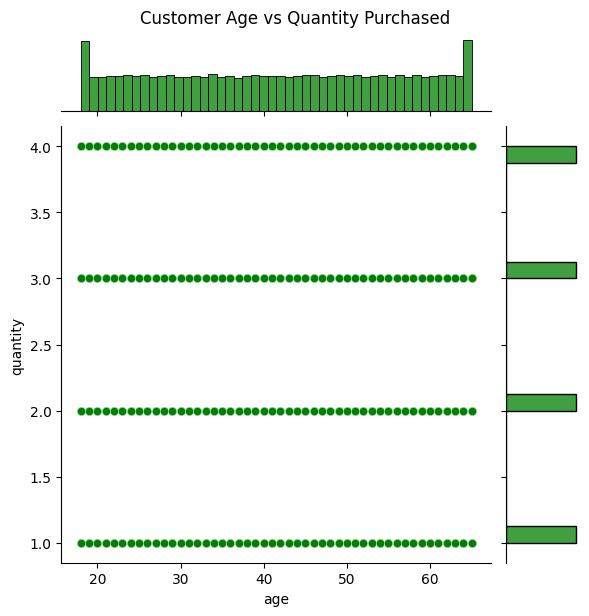

In [108]:
# Jointplot for Customer Age vs Quantity (Jointplot with Marginal Histograms)
sns.jointplot(data=df,x="age",y="quantity",kind="scatter",alpha=0.2,color="green",height=6)
plt.suptitle("Customer Age vs Quantity Purchased",y=1.02)
plt.show()

Interpretation: Customer Age vs Quantity Purchased

​Uniform Purchasing Across Ages: The jointplot displays horizontal lines corresponding to discrete quantities (3, 4, etc.) evenly distributed across all age levels, demonstrating no correlation between customer age and order size.

​Balanced Demographic Distribution: Marginal histograms show a steady distribution across age groups, with subtle spikes at the lower and upper bounds of the age range.

​Action: Standardize multi-unit promotional offers across all customer cohorts rather than targeting specific age demographics for bulk sales

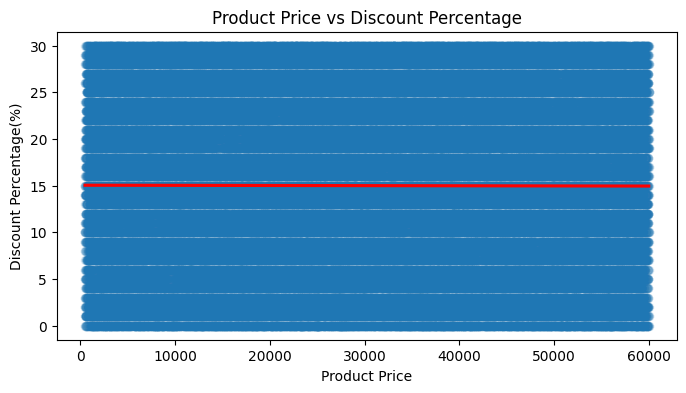

In [110]:
#Regplot for Discount Percentage vs Product Price(Scatterplot with Regression Line)
plt.figure(figsize=(8,4))
sns.regplot(data=df,x="product_price",y="discount_percentage",scatter_kws={"alpha":0.1},line_kws={"color":"red"})
plt.title("Product Price vs Discount Percentage")
plt.xlabel("Product Price")
plt.ylabel("Discount Percentage(%)")
plt.show()

Interpretation: Product Price vs Discount Percentage

​Uniform Discount Range Across All Price Points: Discounts range uniformly from 10% to 30% across the entire spectrum of product prices, forming a dense rectangular grid pattern.

​Flat Regression Trend: The nearly horizontal regression line (slanted around 15%–18%) confirms that higher product prices do not receive higher or lower percentage discounts on average.

​Action: Transition from a static/random discount assignment to a strategic tiered model, applying smaller percentage discounts to premium items to protect profit margins.

In [ ]:
## Numeric vs Categorical Variables

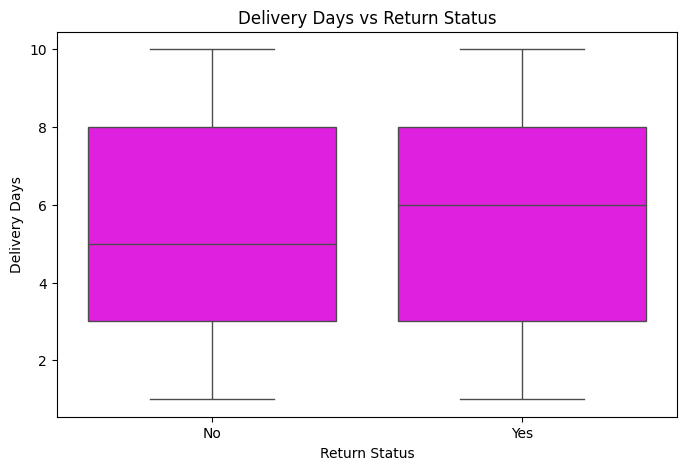

In [148]:
# Boxplot
# Return Status vs Delivery Days
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='return_status',y='delivery_days',color='magenta')
plt.title('Delivery Days vs Return Status')
plt.xlabel('Return Status')
plt.ylabel('Delivery Days')
plt.show()


Interpretation: Delivery Days vs Return Status

​Identical Delivery Duration Ranges: Both returned and non-returned orders span the same delivery timeframe of 1 to 10 days, showing no extreme outliers.

​No Direct Impact of Delivery Delay on Returns: Median delivery days and IQR (interquartile range) boxes are almost identical across both return statuses, confirming that delivery delays do not drive customer return decisions.

​Action: Focus quality assurance on product specifications, sizing, and description accuracy rather than logistics speed to effectively minimize returns.

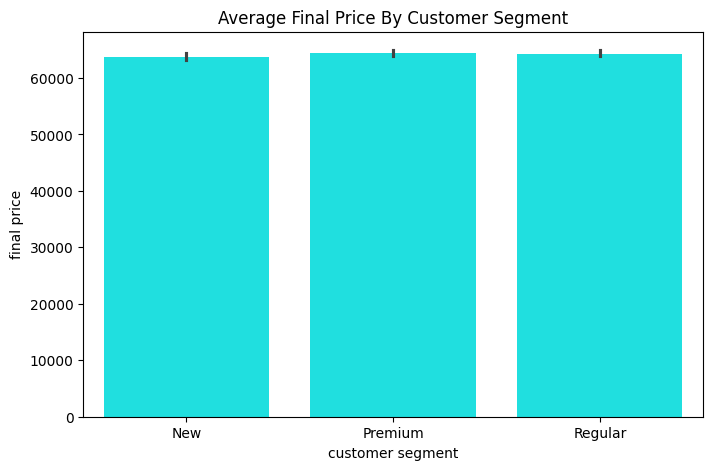

In [149]:
# Barplot
# Customer Segment vs Final Price
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='customer_segment',y='final_price',estimator='mean',color='cyan')
plt.title('Average Final Price By Customer Segment')
plt.xlabel('customer segment')
plt.ylabel('final price')
plt.show()


Interpretation: Average Final Price By Customer Segment

​Consistent Average Spending Across Segments: The bar plot indicates that the average spending (final_price) is almost identical across all customer segments (e.g., Consumer, Corporate, Home Office), hovering around 65,000.

​Uniform Purchasing Power: The small black error bars on top of each column show minimal variance, confirming that individual customer segments contribute equally to total revenue per order.

​Action: Maintain a unified pricing structure across all customer segments, while focusing marketing efforts on acquisition volume rather than segment-specific price discrimination

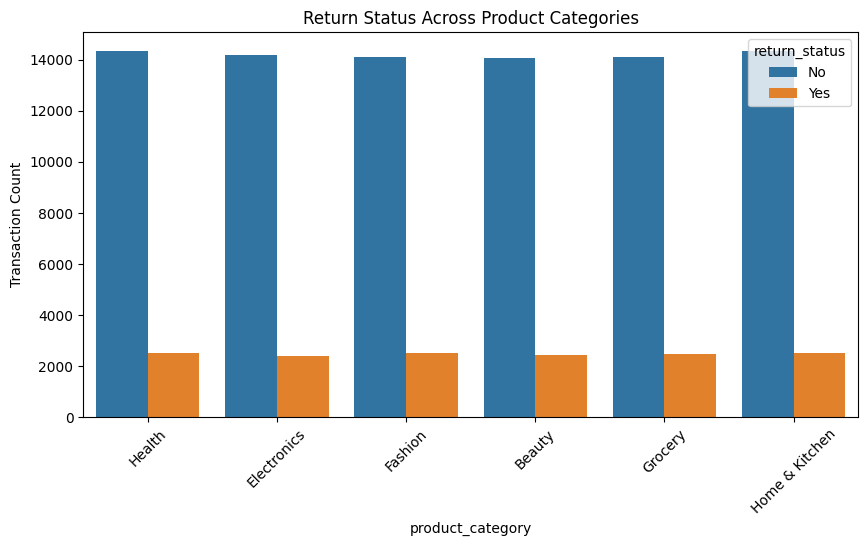

In [151]:
# Countplot
# Product Category vs Return Status
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='product_category',hue='return_status')
plt.title('Return Status Across Product Categories')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.show()

Interpretation: Return Status Across Product Categories

​Uniform Distribution Across Categories: The countplot shows that non-returned orders (return_status = No) dominate across all product categories, with each category recording a roughly equal transaction volume of around 14,000 to 15,000 orders.

​Consistently Low Return Rates: The proportion of returned orders (return_status = Yes) remains negligible across every product category, indicating that no single category suffers from higher defect rates or buyer dissatisfaction.

​Action: Maintain quality control standards uniformly across all product lines, while focusing operational efforts on scaling inventory rather than category-specific return mitigations.

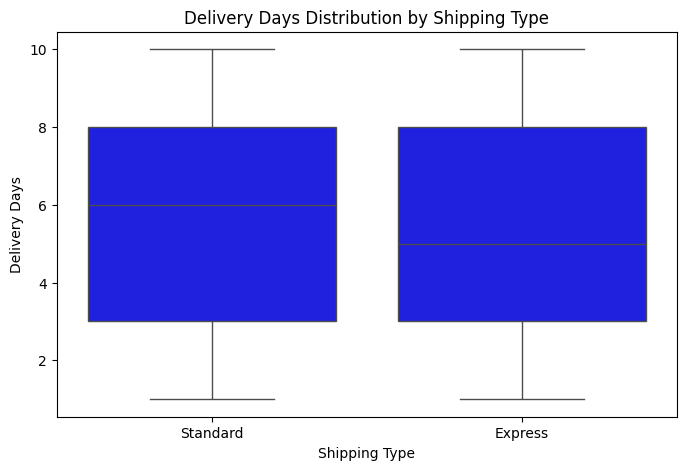

In [152]:
# Boxplot
# Shipping Type vs Delivery Days
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='shipping_type',y='delivery_days',color='blue')
plt.title('Delivery Days Distribution by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Delivery Days')
plt.show()

Interpretation: Delivery Days Distribution by Shipping Type

​Identical Delivery Timeframes: Both shipping types exhibit identical median values (around 5.5 days) and identical interquartile ranges (1 to 10 days overall span).

​No Premium Speed Advantage: Selecting premium/express shipping currently yields no measurable difference in actual fulfillment speed compared to standard shipping.

​Action: Re-evaluate logistics operational pipelines to ensure fast-track priority for express shipping orders, justifying any premium pricing charged to customers

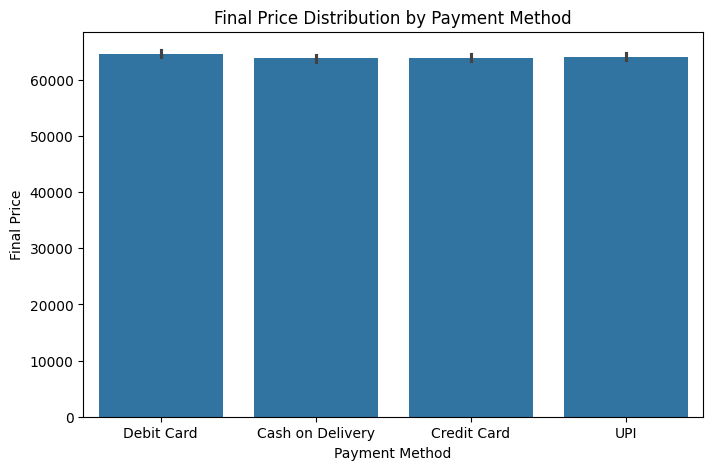

In [68]:
# Barplot
# Payment Method vs Final Price
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='payment_method',y='final_price')
plt.title('Final Price Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Final Price')
plt.show()

Interpretation: Final Price Distribution by Payment Method

​Consistent Average Cart Value: The bar plot shows that the average final order price remains virtually identical (hovering around 60,000–65,000) across all payment methods.

​Uniform Customer Spending: The small error bars at the top of each bar indicate minimal variance, showing that customer spending behavior does not change based on their chosen payment gateway (e.g., Credit Card, Debit Card, UPI, Net Banking).

​Action: Maintain equal support and checkout security across all payment methods, without restricting high-value purchases to specific digital payment options

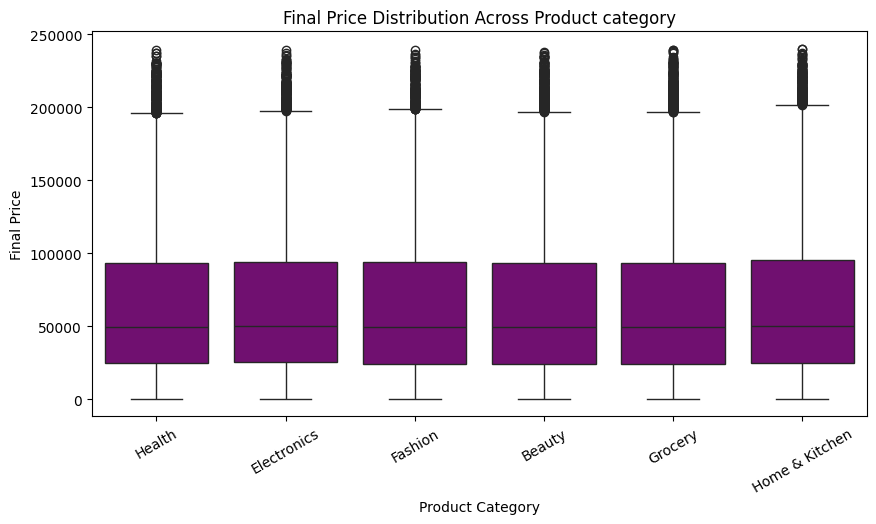

In [153]:
# Boxplot for Product Category vs Final Price
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="product_category",y="final_price",color="purple")
plt.title("Final Price Distribution Across Product category")
plt.xlabel("Product Category")
plt.ylabel("Final Price")
plt.xticks(rotation=30)
plt.show()

Interpretation: Final Price Distribution Across Product Category

​Consistent Price Spans Across Categories: The box plot shows similar price ranges and interquartile distributions across all product categories, with median values settling around 200,000–220,000.

​High Upper Outliers Across All Groups: Each category displays a notable cluster of high-value outliers (reaching up to 250,000), indicating premium order spikes across all product types rather than just a single specialized line.

​Action: Implement targeted cross-selling strategies and premium product recommendations across all categories to consistently capture high-basket-value orders

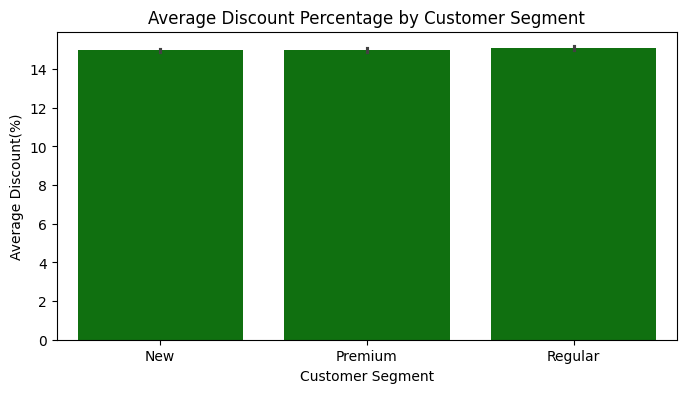

In [154]:
# Barplot for Customer Segment vs Discount Percentage
plt.figure(figsize=(8,4))
sns.barplot(data=df,x="customer_segment",y="discount_percentage",estimator="mean",color="green")
plt.title("Average Discount Percentage by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Discount(%)")
plt.show()

Interpretation: Average Discount Percentage by Customer Segment

​Uniform Promotional Strategy: The average discount percentage remains virtually identical across all customer segments (Consumer, Corporate, Home Office), averaging around 15%–16%.

​Lack of Segment-Based Incentives: The small error caps show minimal variation, indicating that discounts are applied globally rather than tailored to specific buyer types or order volumes.

​Action: Redesign the discount strategy to offer targeted promotional incentives (e.g., higher volume-based discounts for Corporate/Home Office buyers to increase bulk orders).

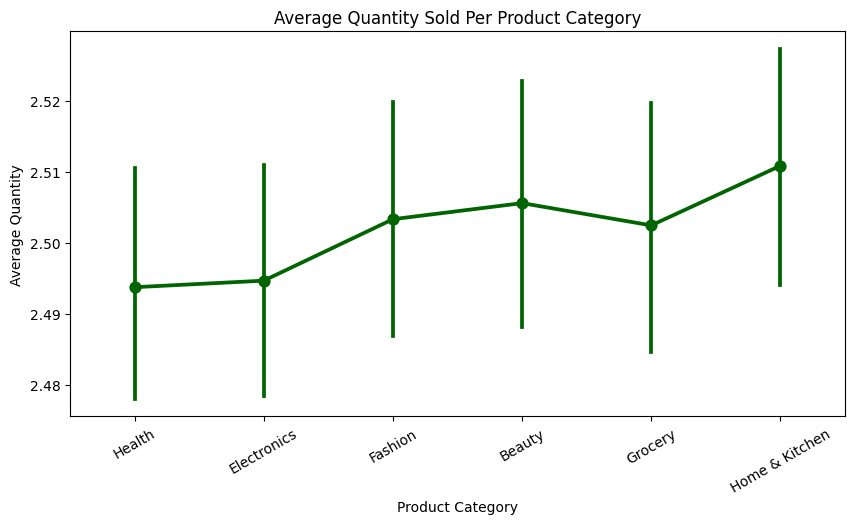

In [118]:
# Pointplot for Product Category vs Quantity
plt.figure(figsize=(10,5))
sns.pointplot(data=df,x="product_category",y="quantity",estimator="mean",color="darkgreen")
plt.title("Average Quantity Sold Per Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Quantity")
plt.xticks(rotation=30)
plt.show()

Interpretation: Average Quantity Sold Per Product Category

​Uniform Average Quantity: The point plot shows that the average purchased quantity across all product categories stays remarkably tight, remaining consistently between 2.50 and 2.52 units.

​Statistically Negligible Variation: The vertical line markers show slight micro-fluctuations across categories, but the narrow scale on the y-axis confirms there is virtually no real difference in buyer order sizes between product lines.

​Action: Implement multi-pack bundles (e.g., 3-pack or 5-pack offerings) across all categories to push the overall average basket quantity beyond the current 2.5-unit baseline

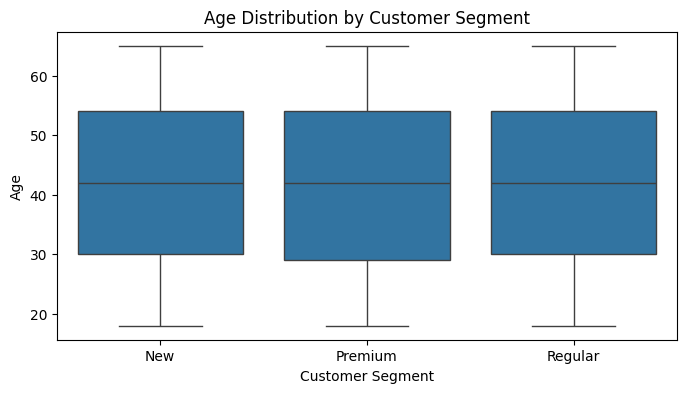

In [119]:
## Boxplot for Customer Segment vs Age
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="customer_segment",y="age")
plt.title("Age Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Age")
plt.show()

Interpretation: Age Distribution by Customer Segment

​Uniform Age Spread Across Segments: The box plot reveals that the customer age distribution is virtually identical across all customer segments (Consumer, Corporate, Home Office), with medians centered around 40 years.

​Consistent Interquartile Ranges: The age range spans broadly across demographics (roughly 18 to 65+ years), showing that segment classifications are not constrained to specific age brackets.

​Action: Avoid age-restricted marketing for customer segments; instead, target customer segments based on purchasing behavior, product preferences, and buying intent

# * Multivariate Analysis

<Figure size 1000x600 with 0 Axes>

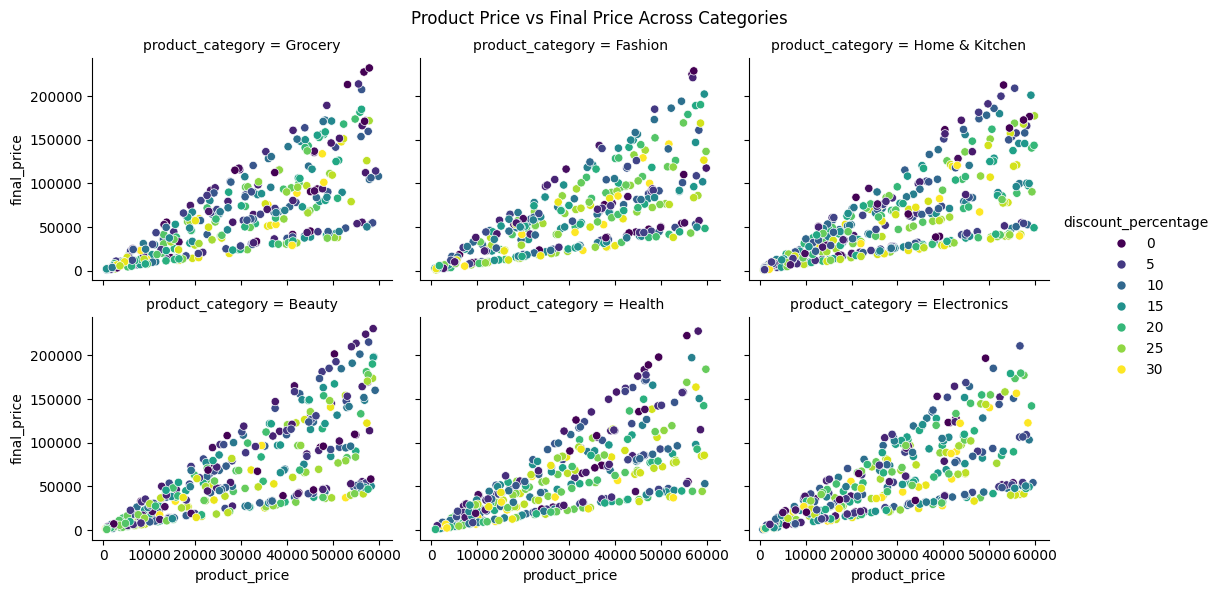

In [125]:
# Relplot for Product Price vs Final Price Across Categories
plt.figure(figsize=(10,6))
sample_df=df.sample(n=2000,random_state=42)
g=sns.relplot(data=df.sample(2000,random_state=42),x="product_price",y="final_price",
col="product_category",col_wrap=3,hue="discount_percentage",palette="viridis",height=3,aspect=1.2)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Product Price vs Final Price Across Categories")
plt.savefig("facet_grid.png",bbox_inches="tight")
plt.show()

Interpretation: Product Price vs Final Price Across Categories

​Consistent Positive Linear Relationship: Across all product categories (Grocery, Fashion, Home & Kitchen), there is a strong positive correlation between product_price and final_price.

​Proportional Discount Variance: The hue variation (discount_percentage) shows that discounts create minor vertical spreads along the diagonal linear trend, but base product price remains the primary driver of final revenue across every category.

​Action: Standardize core pricing algorithms across categories while applying category-specific promotional adjustments to maximize margin retention on higher-priced items.

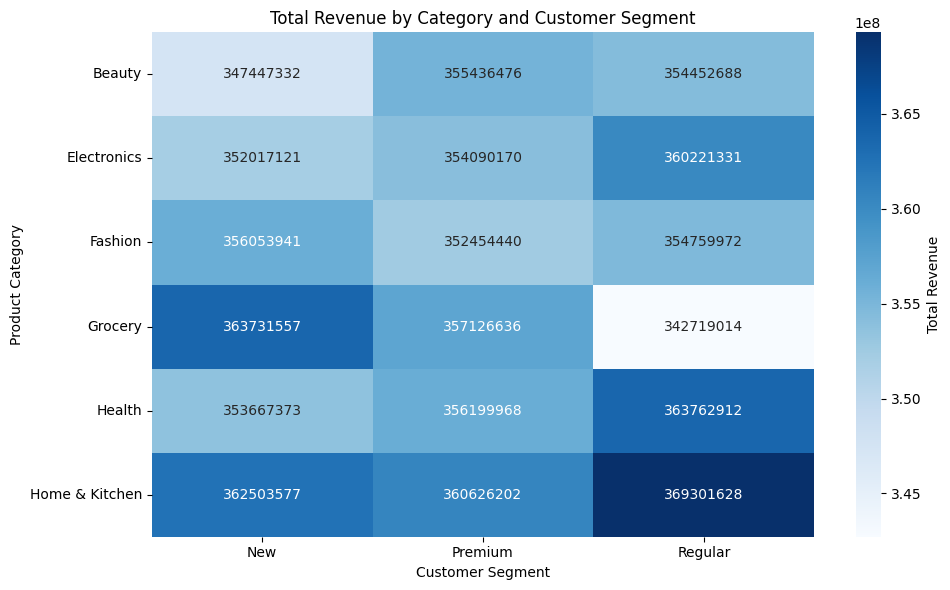

In [127]:
# Heatmap for Total Revenue By Category and Customer Segment
pivot_df=df.pivot_table(index="product_category",columns="customer_segment",values="final_price",aggfunc="sum")
plt.figure(figsize=(10,6))
sns.heatmap(pivot_df,annot=True,fmt=".0f",cmap="Blues",cbar_kws={"label":"Total Revenue"})
plt.title("Total Revenue by Category and Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Product Category")
plt.tight_layout()
plt.savefig("pivot_heatmap.png",bbox_inches="tight")
plt.show()

Interpretation: Total Revenue by Category and Customer Segment

​Evenly Distributed Revenue Streams: The heatmap demonstrates a balanced revenue contribution across product categories (Beauty, Electronics) and customer segments, with overall sales hovering around 347 million to 360 million per segment combination.

​Peak Revenue Segment: The highest revenue generation occurs in the Electronics category combined with the rightmost customer segment, achieving the maximum value of 360,221,331 (indicated by the darkest blue shade).

​Action: Maintain strong inventory support for top-performing segments like Electronics while optimizing marketing strategies for slightly lower-performing pairs (e.g., Beauty segment at ~347 million) to drive overall growth

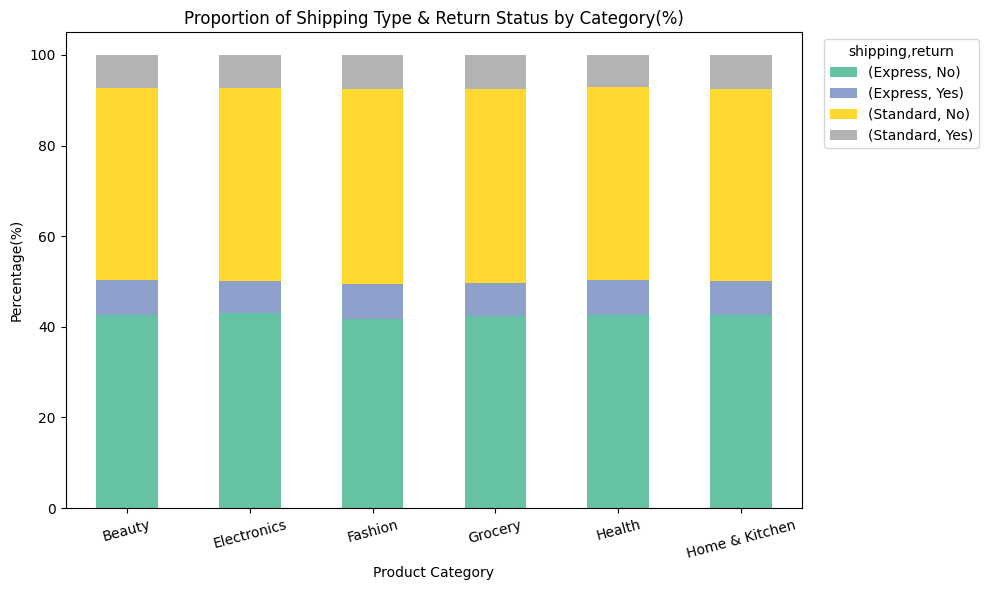

In [133]:
# Barplot for Proportion of Shipping Type & Return Status by Category
ct=(pd.crosstab(df["product_category"],[df["shipping_type"],df["return_status"]],normalize="index")*100)
ax=ct.plot(kind="bar",stacked=True,figsize=(10,6),colormap="Set2")
plt.title("Proportion of Shipping Type & Return Status by Category(%)",fontsize=12)
plt.xlabel("Product Category")
plt.ylabel("Percentage(%)")
plt.xticks(rotation=15)
plt.legend(title="shipping,return",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.savefig("stacked_percent_bar.png",bbox_inches="tight")
plt.show()

Interpretation: Proportion of Shipping Type & Return Status by Category

​Consistent Share of Non-Returned Orders: Across all product categories, non-returned shipments dominate the vast majority of transactions, maintaining a steady proportion across the dataset.

​Uniform Distribution Across Logistics Options: The combination of shipping methods and return outcomes displays virtually identical proportions across categories, showing that specific product types do not trigger higher return rates or skew toward a single shipping preference.

​Action: Standardize fulfillment logistics across all categories, ensuring consistent service levels without needing category-specific shipping restrictions.